In [19]:
from pathlib import Path
import importlib
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parent
SRC_DIR = ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import utils as src_utils
src_utils = importlib.reload(src_utils)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = ROOT / "data"
ZOO_PATH = DATA_DIR / "zoo" / "zoo.csv"

In [20]:
# Load dataset 
X, y = src_utils.load_zoo_features(ZOO_PATH)
X, y = np.asarray(X), np.asarray(y).reshape(-1)
n = len(X)

print(f"Dataset loaded: Zoo | n = {n}")

# ================= ALIASES =================
build_triplets = src_utils.build_cosine_triplets
adds3_sim = src_utils.compute_adds3_similarity
naive_sim = src_utils.naive_similarity
linkage = src_utils.average_linkage_from_similarity
revenue_fn = src_utils.triplet_revenue
aari_fn = src_utils.compute_aari


Dataset loaded: Zoo | n = 100


In [21]:
T = build_triplets(X, k_factor=0.3, noise_rate=0.05, random_state=SEED)

# AddS3
S_adds3 = adds3_sim(n, T)
Z_adds3 = linkage(S_adds3)

# Naive
S_naive = naive_sim(n, T)
Z_naive = linkage(S_naive)

df_ablation1 = pd.DataFrame([
    {
        "Method": "AddS3",
        "Revenue": revenue_fn(Z_adds3, T),
        "AARI": aari_fn(Z_adds3, y)
    },
    {
        "Method": "Naive",
        "Revenue": revenue_fn(Z_naive, T),
        "AARI": aari_fn(Z_naive, y)
    },
])

display(df_ablation1)


,Method,Revenue,AARI
0,AddS3,68934.0,0.357927
1,Naive,51559.0,0.205845


In [22]:
rows = []
for noise in [0.0, 0.05]:
    T = build_triplets(X, k_factor=0.3, noise_rate=noise, random_state=SEED)

    S = adds3_sim(n, T)
    Z = linkage(S)

    rows.append({
        "Noise": noise,
        "Revenue": revenue_fn(Z, T),
        "AARI": aari_fn(Z, y)
    })

df_ablation2 = pd.DataFrame(rows)
display(df_ablation2)

,Noise,Revenue,AARI
0,0.00,71428.0,0.344386
1,0.05,68934.0,0.357927


,k_factor,Revenue,AARI
0,0.1,25533.0,0.173416
1,0.3,68934.0,0.357927
2,0.6,148452.0,0.383603


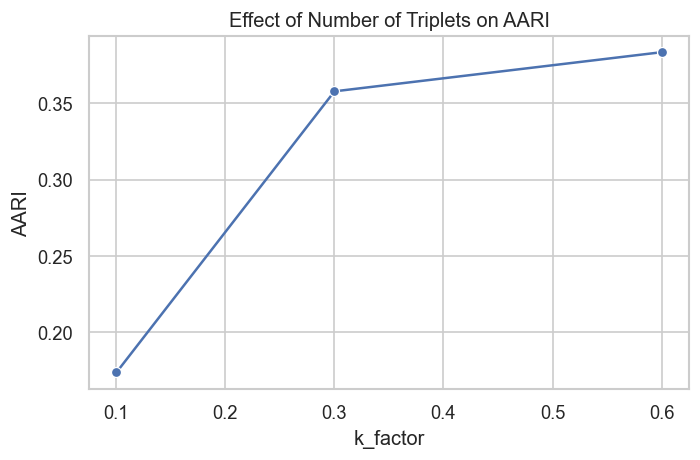

In [23]:

rows = []
for kf in [0.1, 0.3, 0.6]:
    T = build_triplets(X, k_factor=kf, noise_rate=0.05, random_state=SEED)

    S = adds3_sim(n, T)
    Z = linkage(S)

    rows.append({
        "k_factor": kf,
        "Revenue": revenue_fn(Z, T),
        "AARI": aari_fn(Z, y)
    })

df_ablation3 = pd.DataFrame(rows)
display(df_ablation3)

# ================= VISUALIZATION =================
plt.figure(figsize=(6, 4))
sns.lineplot(data=df_ablation3, x="k_factor", y="AARI", marker="o")
plt.title("Effect of Number of Triplets on AARI")
plt.xlabel("k_factor")
plt.ylabel("AARI")
plt.tight_layout()
plt.show()